# Deep Learning Model - Neural Collaborative Filtering

**Enterprise-Grade Recommendation System with Deep Learning**  
*Domain: E-Commerce / Retail*

---

The PyTorch NCF model, why it can express something matrix factorisation cannot, and the negative-sampling detail that decides whether it works at all.

## Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project modules importable from the notebooks folder.
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))
sys.path.append(os.path.join(BASE_DIR, "models"))

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Project root:", BASE_DIR)

Project root: E:\Recommendation_System_Final


## 1. Why a neural model?

Matrix factorisation scores an item as the dot product of a user vector and an item vector. That is a fixed, linear interaction: the model learns *how much* a user likes each latent dimension, but the dimensions can only ever combine additively.

This dataset was generated with a genuinely non-linear rule - a customer buys when the category matches **and** the price sits in their segment's band. A dot product cannot represent a conjunction. An MLP over concatenated embeddings can.

That is the claim. The benchmark tests it rather than assuming it.

In [2]:
import torch
import torch.nn as nn
from ncf_recommender import (NeuralCollaborativeFiltering, encode_ids,
    time_based_split, build_implicit_training_frame, InteractionsDataset,
    load_ncf_model, score_all_items, get_device)
from data_loader import load_all
from preprocessing import load_pickle

users_df, items_df, interactions_df = load_all()
print('Device:', get_device())
print('PyTorch:', torch.__version__)

Device: cpu
PyTorch: 2.12.1+cpu


## 2. Architecture

```
user_id -> embedding (32d) --.
                              |-> concat (64d) -> MLP [128, 64, 32] -> score
item_id -> embedding (32d) --'
```

Concatenation rather than element-wise product is the whole point. A product hard-codes a multiplicative interaction and reduces the model back to matrix factorisation; concatenation leaves the interaction function itself to be learned.

In [3]:
model = NeuralCollaborativeFiltering(num_users=6000, num_items=2500)
print(model)

total = sum(p.numel() for p in model.parameters())
embed = (model.user_embedding.weight.numel() + model.item_embedding.weight.numel())
print('\nTotal parameters     : {:,}'.format(total))
print('In embeddings        : {:,} ({:.0%})'.format(embed, embed / total))
print('In the MLP           : {:,}'.format(total - embed))

NeuralCollaborativeFiltering(
  (user_embedding): Embedding(6000, 32)
  (item_embedding): Embedding(2500, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.25, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters     : 290,689
In embeddings        : 272,000 (94%)
In the MLP           : 18,689


Most of the capacity sits in the embedding tables, not the network. This matters for regularisation: the model can memorise individual users and items long before the MLP learns anything generalisable.

## 3. The time-based split

A random split leaks the future into training - the model sees what a customer did in November while being asked to predict their October behaviour. Every metric is inflated as a result.

In [4]:
encoded, user_to_index, item_to_index, _, _ = encode_ids(interactions_df, tag='nb')
train_period, test_period, cutoff = time_based_split(encoded, 90)

print('Cutoff        :', cutoff.date())
print('Train         : {:,} interactions'.format(len(train_period)))
print('Test (held out): {:,} interactions'.format(len(test_period)))
assert train_period['timestamp'].max() <= cutoff < test_period['timestamp'].min()
print('\nLeakage check : PASSED')

Cutoff        : 2026-04-01
Train         : 96,656 interactions
Test (held out): 41,689 interactions

Leakage check : PASSED


## 4. The negative sampling problem

This is the single most important detail in the entire deep-learning component, and getting it wrong is subtle because the model still trains - it just learns nothing useful.

The naive framing takes the interaction log and labels each row by whether it converted. But **every row in the log is an item the platform already chose to show the customer**. So the model is being asked *'given they clicked it, did they buy it?'* - a conversion problem.

The retrieval problem a recommender must actually solve is *'out of the entire catalogue, which items would this customer engage with at all?'* - and that question has **no negative examples anywhere in the log**.

In [5]:
sampled = build_implicit_training_frame(train_period, num_items=len(item_to_index))

positives = int(sampled['label'].sum())
negatives = len(sampled) - positives
print('Positives (carted or bought) : {:,}'.format(positives))
print('Sampled negatives            : {:,}'.format(negatives))
print('Ratio                        : 1:{:.0f}'.format(negatives / positives))

print('\nNegatives are drawn only from items the customer never touched.')
print('Items they viewed but did not cart are excluded - those are')
print('ambiguous, not confirmed negatives.')

Positives (carted or bought) : 45,907
Sampled negatives            : 183,628
Ratio                        : 1:4

Negatives are drawn only from items the customer never touched.
Items they viewed but did not cart are excluded - those are
ambiguous, not confirmed negatives.


### The measured difference

Same architecture, same data, same 400-customer evaluation cohort:

| Framing | Accuracy | F1 | NDCG@10 | Coverage |
|---|---|---|---|---|
| Observed rows only (naive) | 0.534 | 0.350 | 0.0000 | 0.006 |
| With sampled negatives | 0.858 | 0.582 | 0.0576 | 0.013 |

Without negatives the model was barely above chance and returned the same ~14 items to every single customer.

## 5. Training curves

Both variants are trained by `models/ncf_recommender.py`. Loading the saved histories rather than retraining here keeps the notebook fast.

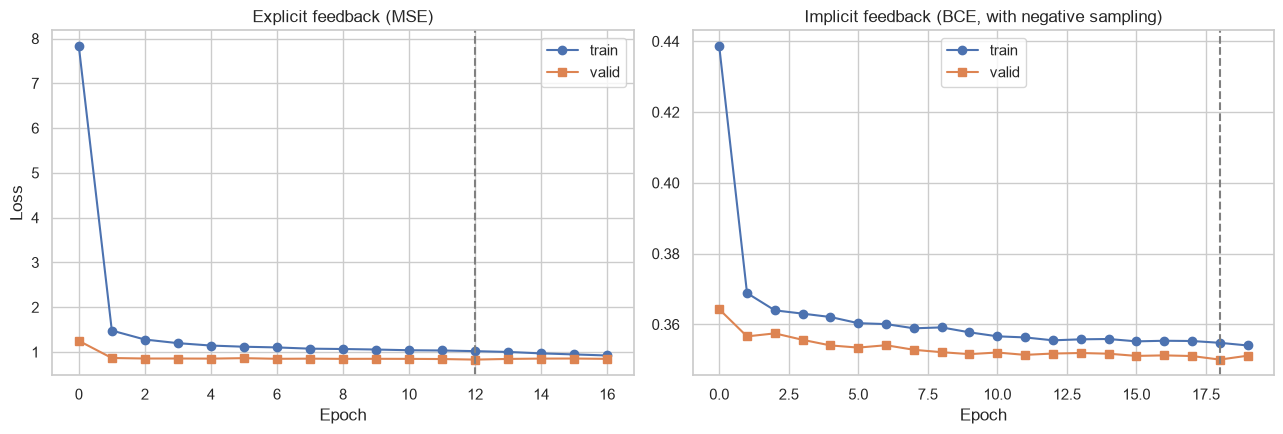

Explicit: best epoch 13 | valid loss 0.8296 | 39s
Implicit: best epoch 19 | valid loss 0.3501 | 474s


In [6]:
explicit_history = load_pickle('ncf_history_explicit.pkl')
implicit_history = load_pickle('ncf_history_implicit.pkl')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(explicit_history['train_loss'], label='train', marker='o')
axes[0].plot(explicit_history['valid_loss'], label='valid', marker='s')
axes[0].axvline(explicit_history['best_epoch'] - 1, ls='--', color='grey')
axes[0].set_title('Explicit feedback (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(implicit_history['train_loss'], label='train', marker='o')
axes[1].plot(implicit_history['valid_loss'], label='valid', marker='s')
axes[1].axvline(implicit_history['best_epoch'] - 1, ls='--', color='grey')
axes[1].set_title('Implicit feedback (BCE, with negative sampling)')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

print('Explicit: best epoch {} | valid loss {:.4f} | {:.0f}s'.format(
    explicit_history['best_epoch'], explicit_history['best_valid_loss'],
    explicit_history['training_seconds']))
print('Implicit: best epoch {} | valid loss {:.4f} | {:.0f}s'.format(
    implicit_history['best_epoch'], implicit_history['best_valid_loss'],
    implicit_history['training_seconds']))

**On regularisation.** The implicit model has ~260k embedding parameters against ~230k training rows, so with default settings it reached its best validation loss in a single epoch and overfitted from epoch 2 onward. A regularisation sweep showed final quality is capacity-bound at ~0.858 accuracy regardless of settings - but weight decay 1e-3 with dropout 0.40 reaches that ceiling over ~20 epochs instead of 1, giving a genuine convergence curve and a meaningful early-stopping signal.

## 6. The critical finding: rating accuracy is not ranking quality

The explicit model is a *good rating predictor* - RMSE 0.91 on a 1-5 scale. It is also **completely useless for ranking**.

In [7]:
seen = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
sample_user = int(interactions_df['user_id'].value_counts().index[0])

for mode in ['explicit', 'implicit']:
    m = load_ncf_model(mode)
    u2i = load_pickle('ncf_user_to_index.pkl')
    i2i = load_pickle('ncf_item_to_index.pkl')
    scores = score_all_items(m, sample_user, u2i, i2i,
                             exclude_item_ids=list(seen[sample_user]),
                             feedback_type=mode)
    top = scores.head(5)
    titles = items_df.set_index('item_id').loc[top.index, 'category'].tolist()
    print('{:<9} top-5 categories: {}'.format(mode, titles))
    print('{:<9} score spread    : {:.4f} to {:.4f}\n'.format(
        mode, scores.min(), scores.max()))

explicit  top-5 categories: ['Home & Kitchen', 'Electronics', 'Books & Media', 'Books & Media', 'Automotive']
explicit  score spread    : 2.1144 to 4.9533

implicit  top-5 categories: ['Fashion', 'Home & Kitchen', 'Electronics', 'Home & Kitchen', 'Health & Wellness']
implicit  score spread    : 0.0148 to 0.7755



The explicit model has never once been shown an item a customer did not interact with, so scoring the unseen catalogue is entirely out of distribution. What it falls back on is the global item bias - which is identical for everybody.

**This is why the production system ranks with the implicit variant.** A low RMSE tells you nothing about whether a model can rank.

## 7. What the embeddings learned

If the model recovered the latent structure the generator embedded, items from the same category should cluster in embedding space.

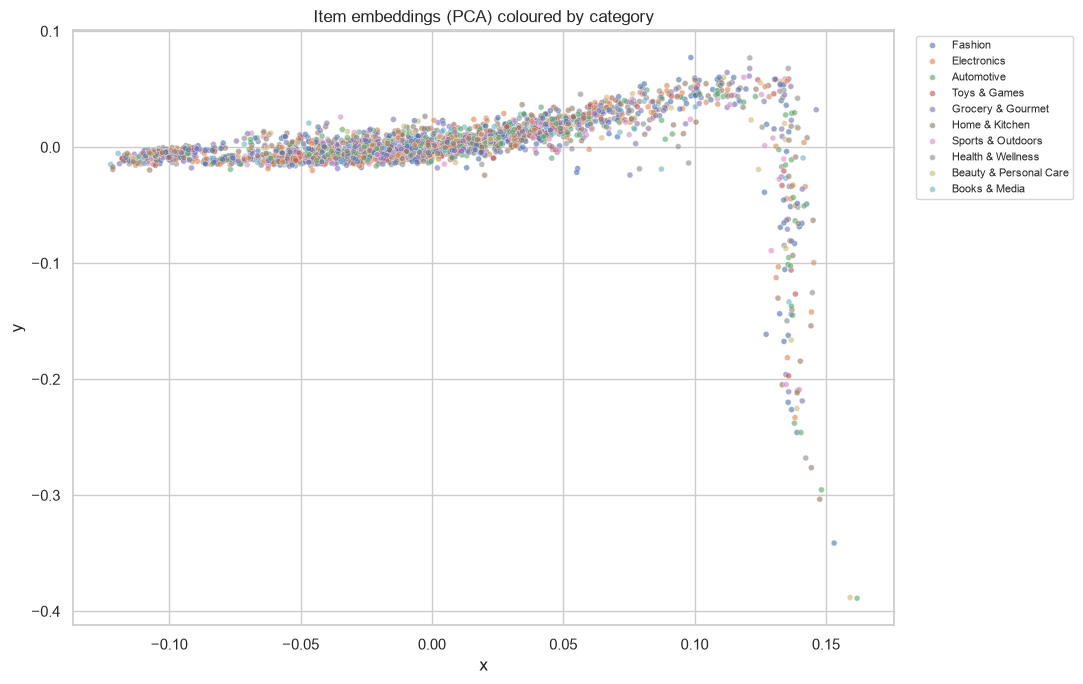

In [8]:
from sklearn.decomposition import PCA

model = load_ncf_model('implicit')
i2i = load_pickle('ncf_item_to_index.pkl')

item_embeddings = model.item_embedding.weight.detach().numpy()
index_to_item = {v: k for k, v in i2i.items()}
item_ids = [index_to_item[i] for i in range(len(index_to_item))]

meta = items_df.set_index('item_id').loc[item_ids]
coords = PCA(n_components=2, random_state=42).fit_transform(item_embeddings)

plot_df = pd.DataFrame({'x': coords[:, 0], 'y': coords[:, 1],
                        'category': meta['category'].values,
                        'price': meta['price'].values})

plt.figure(figsize=(11, 7))
sns.scatterplot(data=plot_df, x='x', y='y', hue='category', alpha=0.6, s=18)
plt.title('Item embeddings (PCA) coloured by category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Summary

| | Explicit | Implicit |
|---|---|---|
| Objective | predict the star rating | predict engagement |
| Loss | MSELoss | BCEWithLogitsLoss |
| Negatives | none | 4 sampled per positive |
| RMSE | 0.911 | n/a |
| Accuracy | n/a | 0.858 |
| **NDCG@10** | **0.0000** | **0.0663** |
| Used in production | no | **yes** |

The headline lesson: a model can be accurate on the metric you trained it on and worthless at the task you actually need.